In [ ]:
# import torch
# import random
# import torch_geometric
import networkx as nx
import matplotlib.pyplot as plt
# from GOOD.data.good_datasets.good_motif2 import GOODMotif2
from GOOD.data.good_datasets.ba_color import BAColor

from torch_geometric.utils import from_networkx, to_networkx

%load_ext autoreload
%autoreload 2

In [2]:
def plot_graph(data):
    G = to_networkx(data, to_undirected=True)
    node_colors = data.x[:, 0].numpy()  # Use the first column to determine color

    plt.figure(figsize=(8, 8))
    pos = nx.spring_layout(G, seed=42)  # For consistent layout
    nx.draw(G, pos, node_color=node_colors, with_labels=True, node_size=700, cmap=plt.cm.RdYlBu, font_weight='bold')

    sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlBu, norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = plt.colorbar(sm)
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(['Color 0', 'Color 1'])

    plt.title("Graph Visualization with Node Colors")
    plt.show()

In [3]:
root = "/mnt/cimec-storage6/users/steve.azzolin/sedignn/leci_private_fork/storage/datasets/BAColor"
dataset = BAColor(root)

print(f'Dataset contains {len(dataset)} graphs')
# print('Sample graph:', dataset[0])


loading:  /mnt/cimec-storage6/users/steve.azzolin/sedignn/leci_private_fork/storage/datasets/BAColor/processed/data_numgraphs5000_min10_max100.pt
Dataset contains 5000 graphs


In [6]:
dataset[0]

Data(x=[39, 2], edge_index=[2, 144], y=[1])

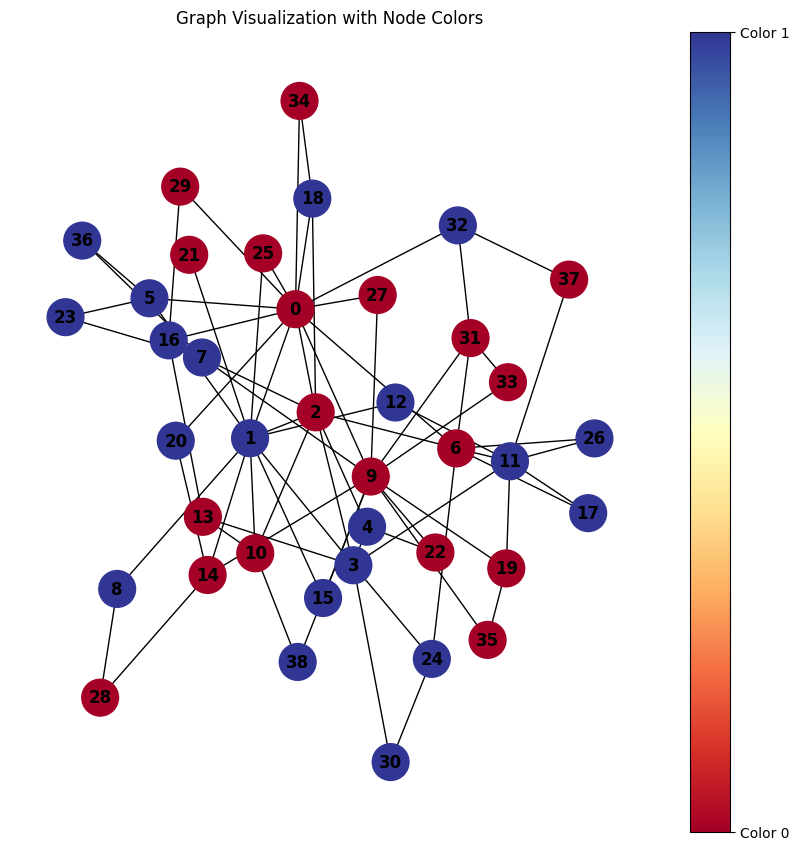

In [7]:
plot_graph(dataset[0])

In [11]:
BAColor.load(root)

loading:  /mnt/cimec-storage6/users/steve.azzolin/sedignn/leci_private_fork/storage/datasets/BAColor/processed/data_numgraphs5000_min10_max100.pt


({'train': BAColor(4000),
  'id_val': BAColor(500),
  'id_test': BAColor(500),
  'metric': 'Accuracy',
  'task': 'Multi-label classification',
  'val': BAColor(500),
  'test': BAColor(500)},
 Munch({'dataset_type': 'syn', 'model_level': 'graph', 'dim_node': 2, 'dim_edge': 0, 'edge_feat_dims': 0, 'num_envs': 1, 'num_classes': 2}))

## MNIST

In [21]:
import torch
import numpy as np
import random

from GOOD.data.good_datasets.mnist import MNIST
import GOOD.kernel.pipelines.xai_metric_utils as xai_utils
from torch_geometric.utils import to_networkx, from_networkx, to_undirected, sort_edge_index, shuffle_node, is_undirected, contains_self_loops, contains_isolated_nodes, coalesce, subgraph

In [22]:
def reset_random_seed(seed, fixed_seed=None):
    # Fix Random seed
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

    # Default state is a training state
    torch.enable_grad()

def get_color_based_on_dataset(dataset_name, x):
    if "BAColorGV" in dataset_name or "BAColorRB" in dataset_name:
        # elif node_attr[i] == [1., 0., 0., 0.]:
        #     node_colors.append("red")
        # elif node_attr[i] == [0., 1., 0., 0.]:
        #     node_colors.append("blue")
        # elif node_attr[i] == [0., 0., 1., 0.]:
        #     node_colors.append("green")
        # elif node_attr[i] == [0., 0., 0., 1.]:
        #     node_colors.append("violet")
        if np.argmax(x) == 0:
            return "red"
        elif np.argmax(x) == 1:
            return "blue"
        elif np.argmax(x) == 2:
            return "green"
        elif np.argmax(x) == 3:
            return "violet"
        else:
            return "orange"
    elif dataset_name == "MNIST":
        return x[:3]

def draw_colored(dataset_name, G, name, thrs, node_expl=None, edge_expl="", subfolder="", pos=None, save=True, figsize=(6.4, 4.8), nodesize=150, with_labels=True, title=None, ax=None):
    plt.figure(figsize=figsize)

    node_gt = list(nx.get_node_attributes(G, "node_gt").values())
    node_attr = list(nx.get_node_attributes(G, "x").values())
    
    if pos is None and dataset_name != "MNIST":
        pos = nx.kamada_kawai_layout(G)
    elif dataset_name == "MNIST":
        pos = [ (x[4], -x[3])  for x in node_attr]
    
    node_colors = []
    for i in range(len(node_attr)):
        if len(node_gt) > 0 and node_gt[i]:
            node_colors.append("orange") # "lightgreen"
        elif len(node_gt) > 0 and not node_gt[i]:
            node_colors.append("blue") # "lightgreen"
        else:
            node_colors.append(get_color_based_on_dataset(dataset_name, node_attr[i]))

    nx.draw(
        G,
        with_labels=with_labels,
        pos=pos,
        ax=ax,
        node_size=nodesize,
        node_color=node_colors,
        # edge_color=edge_color,
        alpha=0.9 if dataset_name == "MNIST" else 0.5
    )


    # if node_expl is not None:
    #     node_labels = {u: "E" if score >= thrs else "" for u, score in enumerate(node_expl)}
    # else:
    #     assert False, "Not implemented"
    #     edge_color = list(nx.get_edge_attributes(G, "attn_weight").values())
    #     edge_color = ["red" if e >= thrs else "black" for e in edge_color]

    # nx.draw_networkx_labels(
    #     G,
    #     pos,
    #     node_labels,
    #     font_size=12,
    #     font_color="red" if dataset_name == "MNIST" else "black",
    #     alpha=0.6
    # )

    # Annotate with node scores
    if node_expl is not None and pos is not None:
        if isinstance(pos, dict):
            label_pos = {n: (x, y + 0.04) for n, (x, y) in pos.items()}  # vertical offset
        else:
            label_pos = {n: (x, y + 0.04) for n, (x, y) in enumerate(pos)}  # vertical offset

        nx.draw_networkx_labels(
            G,
            label_pos,
            labels={n: f"{v:.2f}" for n, v in enumerate(node_expl)},
            font_size=6,
            alpha=0.8
        )
    
    plt.suptitle(title)
    plt.show()

    if ax is None:
        plt.close()
    return pos

In [34]:
reset_random_seed(seed=1 * 97 + 13)

train_set = MNIST("/home/azzolin/sedignn/expl_shortcut/storage/datasets/MNIST/", domain="basis", mode="train")

n_train_data, n_val_data = 20000, 5000
# perm_idx = torch.randperm(len(train_set))     
# train_val = train_set[perm_idx]   
train_val = train_set

# train_dataset = train_val[:n_train_data]
# id_val_dataset = train_val[-n_val_data:]

/home/azzolin/venv/explshct/lib/python3.8/site-packages/torch_geometric/data/dataset.py:213: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  if osp.exists(f) and torch.load(f)

In [37]:
one_idxs = torch.nonzero(train_val.y == 1).view(-1)

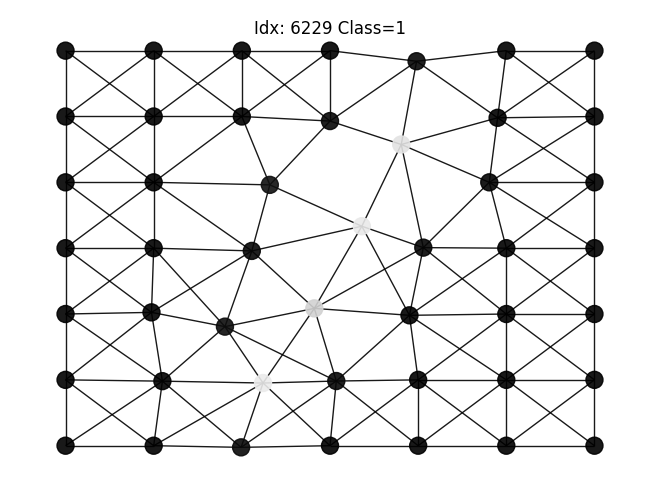

In [105]:
idx = one_idxs[699]

g = train_val[idx]
G = to_networkx(g, node_attrs=["x"], to_undirected=True)
draw_colored(
    "MNIST",
    G,
    node_expl=None,
    subfolder=None,
    name=f"debug_fid_{idx}",
    thrs=0.5,
    title=f"Idx: {idx} Class={int(g.y.item())}",
    with_labels=False,
    figsize=(6.4, 4.8)
);

In [33]:
inverse_perm = torch.argsort(perm_idx)

original_index = inverse_perm[idx]

original_index

tensor(25213)